In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

# 1. CONFIGURAÇÃO — ajuste os caminhos das pastas no Drive

pastas = {
    "YOLO26-n": "/content/drive/MyDrive/parking_monitor_resultados_Yolo26n",
    "YOLO26-s": "/content/drive/MyDrive/parking_monitor_resultados_Yolo26s",
    "YOLO26-m": "/content/drive/MyDrive/parking_monitor_resultados_Yolo26m",
    "RT-DETR": "/content/drive/MyDrive/resultados_rtdetr",

}

cores = {"YOLO26-n": "tab:blue", "YOLO26-s": "tab:orange", "YOLO26-m": "tab:green" , "RT-DETR": "tab:red"}

dfs = {}
for nome, pasta in pastas.items():
    csv_path = Path(pasta) / "results.csv"
    df = pd.read_csv(csv_path)
    df.columns = df.columns.str.strip()
    dfs[nome] = df


for nome, df in dfs.items():
    print(f"\n{nome}: {df.columns.tolist()}")


YOLO26-n: ['epoch', 'time', 'train/box_loss', 'train/cls_loss', 'train/dfl_loss', 'metrics/precision(B)', 'metrics/recall(B)', 'metrics/mAP50(B)', 'metrics/mAP50-95(B)', 'val/box_loss', 'val/cls_loss', 'val/dfl_loss', 'lr/pg0', 'lr/pg1', 'lr/pg2']

YOLO26-s: ['epoch', 'time', 'train/box_loss', 'train/cls_loss', 'train/dfl_loss', 'metrics/precision(B)', 'metrics/recall(B)', 'metrics/mAP50(B)', 'metrics/mAP50-95(B)', 'val/box_loss', 'val/cls_loss', 'val/dfl_loss', 'lr/pg0', 'lr/pg1', 'lr/pg2']

YOLO26-m: ['epoch', 'time', 'train/box_loss', 'train/cls_loss', 'train/dfl_loss', 'metrics/precision(B)', 'metrics/recall(B)', 'metrics/mAP50(B)', 'metrics/mAP50-95(B)', 'val/box_loss', 'val/cls_loss', 'val/dfl_loss', 'lr/pg0', 'lr/pg1', 'lr/pg2']

RT-DETR: ['epoch', 'time', 'train/giou_loss', 'train/cls_loss', 'train/l1_loss', 'metrics/precision(B)', 'metrics/recall(B)', 'metrics/mAP50(B)', 'metrics/mAP50-95(B)', 'val/giou_loss', 'val/cls_loss', 'val/l1_loss', 'lr/pg0', 'lr/pg1', 'lr/pg2', 'lr/p

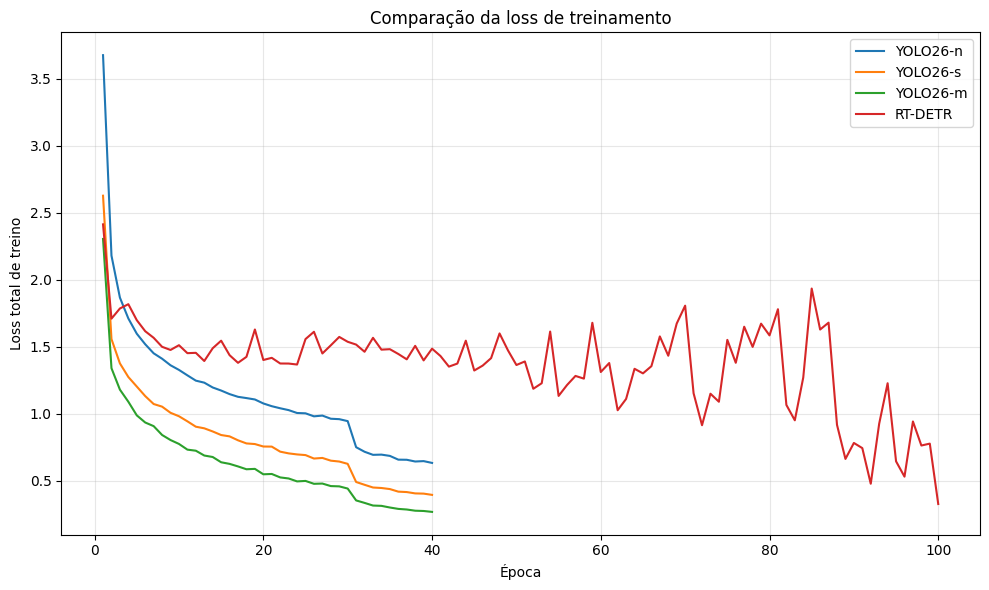

In [2]:

# 2. LOSS TOTAL DE TREINO — todos juntos

plt.figure(figsize=(10, 6))
for nome, df in dfs.items():
    colunas_loss = [c for c in ["train/box_loss", "train/cls_loss", "train/dfl_loss",
                                  "train/giou_loss", "train/l1_loss"] if c in df.columns]
    loss_total = df[colunas_loss].sum(axis=1)
    plt.plot(df["epoch"], loss_total, label=nome, color=cores[nome])

plt.xlabel("Época")
plt.ylabel("Loss total de treino")
plt.title("Comparação da loss de treinamento")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("comparacao_loss_treino.png", dpi=150)
plt.show()

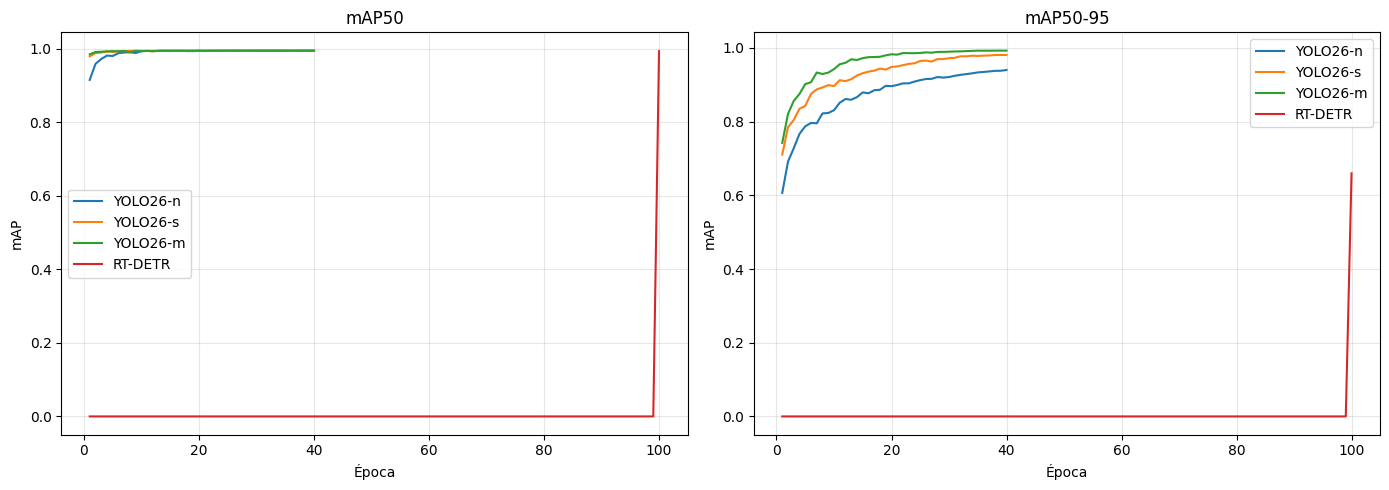

In [3]:

# 3. mAP50 e mAP50-95 — todos juntos (2 subplots)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for nome, df in dfs.items():
    if "metrics/mAP50(B)" in df.columns:
        axes[0].plot(df["epoch"], df["metrics/mAP50(B)"], label=nome, color=cores[nome])
    if "metrics/mAP50-95(B)" in df.columns:
        axes[1].plot(df["epoch"], df["metrics/mAP50-95(B)"], label=nome, color=cores[nome])

axes[0].set_title("mAP50")
axes[1].set_title("mAP50-95")
for ax in axes:
    ax.set_xlabel("Época")
    ax.set_ylabel("mAP")
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("comparacao_map.png", dpi=150)
plt.show()

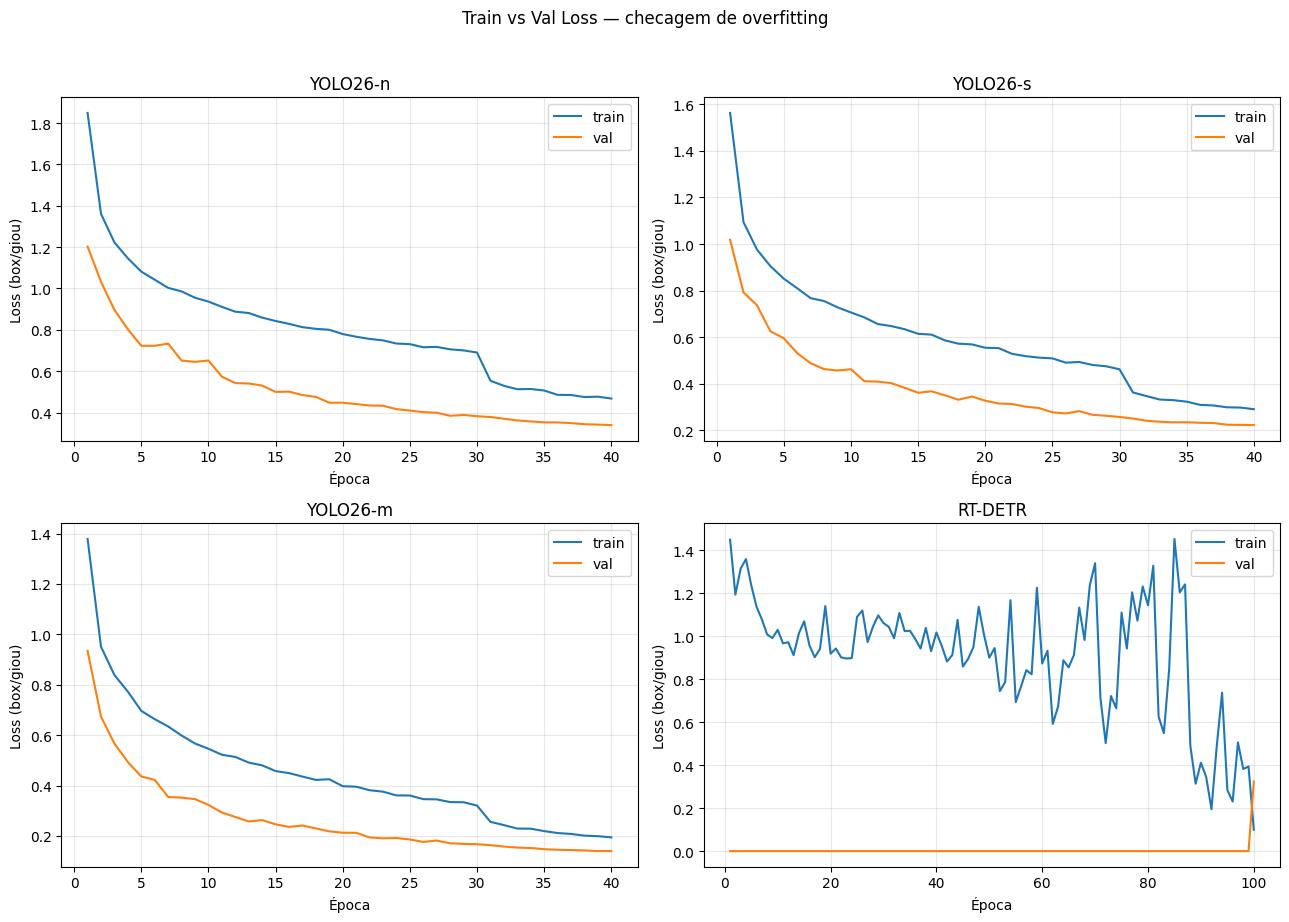

In [4]:

# 4. TRAIN vs VAL LOSS por modelo — checar overfitting (4 subplots)

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
axes = axes.flatten()

for ax, (nome, df) in zip(axes, dfs.items()):
    # box_loss é comum a quase todos; se não existir, tenta o equivalente
    train_col = "train/box_loss" if "train/box_loss" in df.columns else "train/giou_loss"
    val_col = "val/box_loss" if "val/box_loss" in df.columns else "val/giou_loss"

    if train_col in df.columns:
        ax.plot(df["epoch"], df[train_col], label="train")
    if val_col in df.columns:
        ax.plot(df["epoch"], df[val_col], label="val")

    ax.set_title(nome)
    ax.set_xlabel("Época")
    ax.set_ylabel("Loss (box/giou)")
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle("Train vs Val Loss — checagem de overfitting", y=1.02)
plt.tight_layout()
plt.savefig("comparacao_overfitting.png", dpi=150)
plt.show()

          precision   recall    mAP50  mAP50-95
modelo                                         
YOLO26-n    0.99341  0.99350  0.99449   0.94019
YOLO26-s    0.99724  0.99719  0.99470   0.98095
YOLO26-m    0.99740  0.99774  0.99476   0.99277
RT-DETR     0.99589  0.99856  0.99332   0.65982


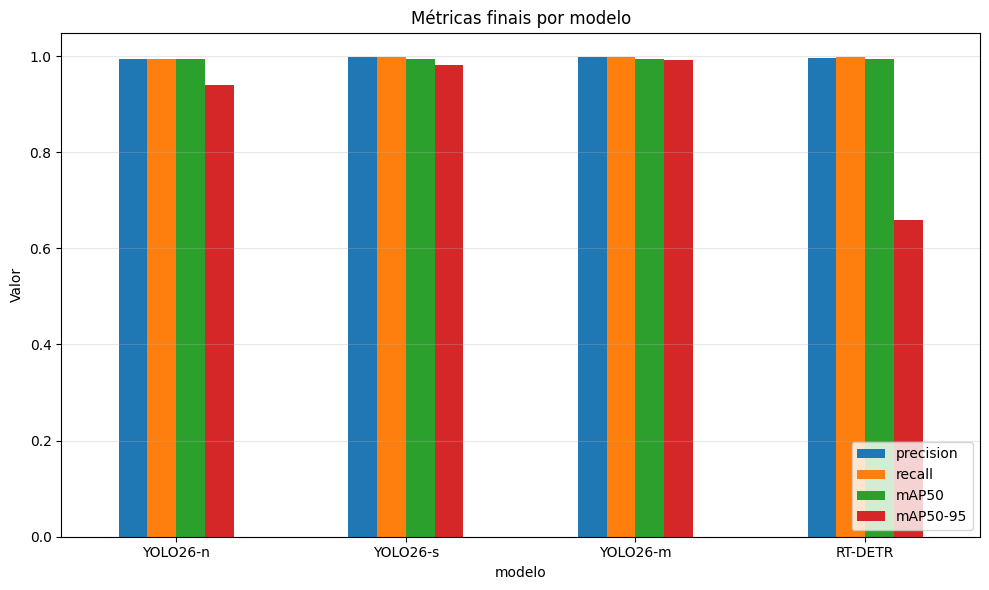

In [5]:

# 5. PRECISION, RECALL, mAP50, mAP50-95 FINAIS — gráfico de barras

metricas_finais = []
for nome, df in dfs.items():
    ultima_linha = df.iloc[-1]
    metricas_finais.append({
        "modelo": nome,
        "precision": ultima_linha.get("metrics/precision(B)", np.nan),
        "recall": ultima_linha.get("metrics/recall(B)", np.nan),
        "mAP50": ultima_linha.get("metrics/mAP50(B)", np.nan),
        "mAP50-95": ultima_linha.get("metrics/mAP50-95(B)", np.nan),
    })

df_final = pd.DataFrame(metricas_finais).set_index("modelo")
print(df_final)

df_final.plot(kind="bar", figsize=(10, 6))
plt.title("Métricas finais por modelo")
plt.ylabel("Valor")
plt.xticks(rotation=0)
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.savefig("comparacao_metricas_finais.png", dpi=150)
plt.show()

In [6]:
!pip install -U ultralytics pycocotools -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.8/41.8 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 45.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.2/53.2 kB 4.0 MB/s eta 0:00:00


     modelo     tempo_ms  mAP50-95
0  YOLO26-n   107.699895   0.94019
1  YOLO26-s   341.882110   0.98095
2  YOLO26-m   710.143816   0.99277
3   RT-DETR  2656.437588   0.65982


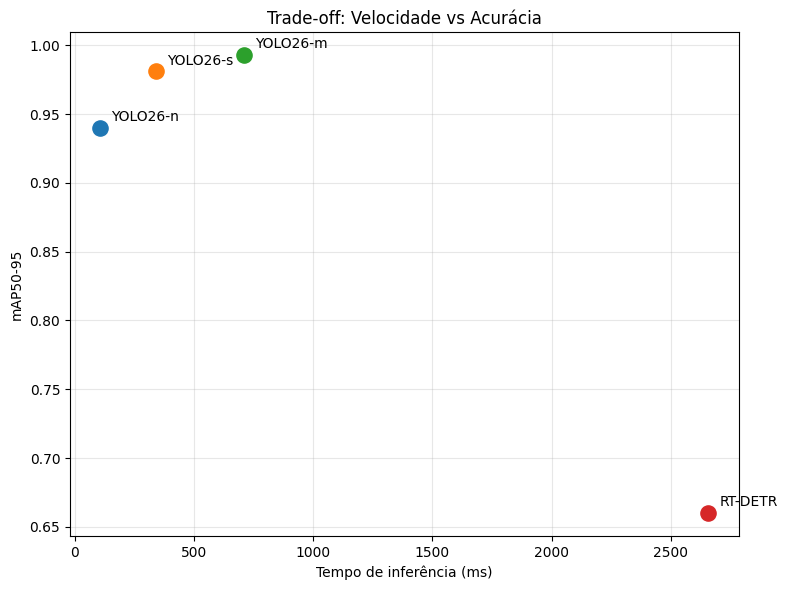

In [8]:

# 6. TRADE-OFF: Velocidade vs Acurácia

from ultralytics import YOLO
import time
import cv2

pesos = {
    "YOLO26-n": "/content/drive/MyDrive/parking_yolo26n_best.pt",
    "YOLO26-s": "/content/drive/MyDrive/parking_yolo26s_best.pt",
    "YOLO26-m": "/content/drive/MyDrive/parking_yolo26m_best.pt",
    "RT-DETR": "/content/drive/MyDrive/rtdetr_best.pt",
}

# Carrega a imagem real uma única vez
caminho_imagem_teste = "/content/drive/MyDrive/img1.jpg"
imagem_teste = cv2.imread(caminho_imagem_teste)

if imagem_teste is None:
    raise FileNotFoundError(f"Não foi possível carregar a imagem em {caminho_imagem_teste}")

resultados_benchmark = []
for nome, peso in pesos.items():
    modelo = YOLO(peso)
    info = modelo.info(verbose=False)

    # benchmark de tempo de inferência com a imagem real
    _ = modelo.predict(imagem_teste, verbose=False)  # warmup
    inicio = time.time()
    for _ in range(20):
        _ = modelo.predict(imagem_teste, verbose=False)
    tempo_medio_ms = (time.time() - inicio) / 20 * 1000

    resultados_benchmark.append({
        "modelo": nome,
        "tempo_ms": tempo_medio_ms,
        "mAP50-95": df_final.loc[nome, "mAP50-95"],
    })

df_bench = pd.DataFrame(resultados_benchmark)
print(df_bench)

plt.figure(figsize=(8, 6))
for _, linha in df_bench.iterrows():
    plt.scatter(linha["tempo_ms"], linha["mAP50-95"], s=120, color=cores[linha["modelo"]])
    plt.annotate(linha["modelo"], (linha["tempo_ms"], linha["mAP50-95"]),
                 textcoords="offset points", xytext=(8, 5), fontsize=10)

plt.xlabel("Tempo de inferência (ms)")
plt.ylabel("mAP50-95")
plt.title("Trade-off: Velocidade vs Acurácia")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("comparacao_tradeoff.png", dpi=150)
plt.show()

In [9]:
from ultralytics import RTDETR

caminho_modelo = "/content/drive/MyDrive/rtdetr_best.pt"
modelo = RTDETR(caminho_modelo)

print(modelo.names)

novos_nomes = {0: "Vazio", 1: "Ocupado"}
modelo.model.names = novos_nomes

print(modelo.names)

{0: 'space-empty', 1: 'space-occupied'}
{0: 'Vazio', 1: 'Ocupado'}


In [10]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from ultralytics import YOLO
from pathlib import Path


# 1. CONFIGURAÇÃO

pesos = {
    "YOLO26-n": "/content/drive/MyDrive/parking_yolo26n_best.pt",
    "YOLO26-s": "/content/drive/MyDrive/parking_yolo26s_best.pt",
    "YOLO26-m": "/content/drive/MyDrive/parking_yolo26m_best.pt",
    "RT-DETR": modelo,

}

# Mesmas imagens de teste para todos os modelos (use 2-3 imagens representativas)
imagens_teste = [
    "/content/drive/MyDrive/img1.jpg",
    "/content/drive/MyDrive/img2.jpg",
    "/content/drive/MyDrive/img3.jpg",
]

# Ajuste conforme os nomes das suas classes no dataset
NOME_EMPTY = "Vazio"
NOME_OCC = "Ocupado"

CONF_THRESHOLD = 0.25  # mesmo threshold para todos, pra comparação justa

In [11]:

# 2. FUNÇÃO QUE DESENHA AS CAIXAS + TEXTO NO TOPO

def desenhar_predicao(modelo, caminho_imagem, conf=CONF_THRESHOLD):
    resultado = modelo.predict(caminho_imagem, conf=conf, verbose=False)[0]
    img = cv2.imread(caminho_imagem)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    nomes_classes = resultado.names
    n_empty, n_occ = 0, 0
    confs = []

    for box in resultado.boxes:
        cls_id = int(box.cls[0])
        nome_classe = nomes_classes[cls_id]
        confianca = float(box.conf[0])
        x1, y1, x2, y2 = map(int, box.xyxy[0])

        if nome_classe == NOME_EMPTY:
            cor = (0, 255, 0)  # verde
            n_empty += 1
        elif nome_classe == NOME_OCC:
            cor = (255, 0, 0)  # vermelho
            n_occ += 1
        else:
            cor = (255, 255, 0)

        confs.append(confianca)
        cv2.rectangle(img, (x1, y1), (x2, y2), cor, 2)

    conf_media = np.mean(confs) if confs else 0.0
    return img, n_empty, n_occ, conf_media

In [12]:

# 3. MONTAR A GRADE (linhas = modelos, colunas = imagens)

n_modelos = len(pesos)
n_imagens = len(imagens_teste)

fig, axes = plt.subplots(n_modelos, n_imagens, figsize=(5 * n_imagens, 5 * n_modelos))

for i, (nome_modelo, caminho_peso) in enumerate(pesos.items()):
    modelo = YOLO(caminho_peso)

    for j, caminho_img in enumerate(imagens_teste):
        img, n_empty, n_occ, conf_media = desenhar_predicao(modelo, caminho_img)

        ax = axes[i, j] if n_modelos > 1 else axes[j]
        ax.imshow(img)
        ax.set_title(f"Vazio: {n_empty} | Ocupado: {n_occ}\nAvg Conf: {conf_media:.2f}", fontsize=11)
        ax.axis("off")

        # Nome do modelo só na primeira coluna, como rótulo lateral
        if j == 0:
            ax.text(-0.15, 0.5, nome_modelo, transform=ax.transAxes,
                     fontsize=14, fontweight="bold", color="white",
                     ha="center", va="center", rotation=90,
                     bbox=dict(boxstyle="round,pad=0.5", facecolor="#1f77b4"))

plt.tight_layout()
plt.savefig("/content/comparacao_visual_modelos.png", dpi=150, bbox_inches="tight")
plt.show()

#import shutil
#shutil.copy("/content/comparacao_visual_modelos.png", "/content/drive/MyDrive/comparacao_visual_modelos.png")
#print("✅ Comparação visual salva no Drive!")

Output hidden; open in https://colab.research.google.com to view.